In [1]:
# Import required libraries.
import random
import operator
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

### Helper Functions

In [2]:
# Make a random individual.
def generate_individual(size, pos_min, pos_max):
    individual = creator.Individual(random.uniform(pos_min, pos_max) for _ in range(size))
    return individual


def mutate_adaptive_es(current_individual, sigma):
    # Add a random change to each variable.
    r = [random.gauss(0, sigma) for _ in range(len(current_individual))]

    # Make the new individual.
    new_individual = creator.Individual(
        list(
            map(
                operator.add,
                current_individual,
                r
            )
        )
    )

    return new_individual


# Define fitness functions.
def evaluation_rosenbrock(individual):
    fitness = sum(100 * (individual[i] ** 2 - individual[i + 1]) ** 2 + (individual[i] - 1) ** 2 for i in range(len(individual) - 1))
    return (fitness,)


def evaluation_griewank(individual):
    sum_part = sum(x ** 2 / 4000 for x in individual)
    product_part = math.prod(math.cos(x / math.sqrt(i + 1)) for i, x in enumerate(individual))

    fitness = sum_part - product_part + 1

    return (fitness,)

### Configuration variables

In [3]:
# Number of decision variables.
NUM_DECISION_VARIABLES = 50

# Population and generation limits.
POPULATION_SIZE = 50
NUM_OF_GEN = 1000

# Search space bounds.
POS_MIN = -30
POS_MAX = 30

# Select the fitness function.
EVALUATION_FUNC_NAME = "evaluation_rosenbrock"

EVALUATION_FUNCTIONS = {
    "evaluation_rosenbrock": evaluation_rosenbrock,
    "evaluation_griewank": evaluation_griewank
}

# Adaptive ES parameters.
ADAPTIVE_ES_C = 0.817
ADAPTIVE_ES_SIGMA = 10
ADAPTIVE_ES_WINDOW_LENGTH = min(NUM_DECISION_VARIABLES, 30)

### Toolbox

In [4]:
# Create DEAP classes.
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Configure the toolbox.
toolbox = base.Toolbox()

toolbox.register("individual",
                 generate_individual,
                 size=NUM_DECISION_VARIABLES,
                 pos_min=POS_MIN,
                 pos_max=POS_MAX)

toolbox.register("mutate", mutate_adaptive_es)

# Register the fitness function.
toolbox.register("evaluate", EVALUATION_FUNCTIONS[EVALUATION_FUNC_NAME])

### Adaptive ES Algorithm

In [5]:
# Run ES for each seed.
seed_list = list(range(1, 31))
results = []
# Keep the latest seed's convergence data.
convergence_data = []

for seed in seed_list:
    random.seed(seed)
    
    # Create and evaluate the initial solution.
    initial_individual = toolbox.individual()
    initial_individual.fitness.values = toolbox.evaluate(initial_individual)
    current_individual = initial_individual
    best_fitness_by_generation = [current_individual.fitness.values[0]]

    # Reset the ES values for each run.
    sigma = ADAPTIVE_ES_SIGMA
    mutation_success_history = []
    
    for gen in range(NUM_OF_GEN):
        is_mutation_success = 0
        # Create an offspring.
        new_mutated_individual = toolbox.mutate(current_individual, sigma)
        new_mutated_individual.fitness.values = toolbox.evaluate(new_mutated_individual)

        # Accept only improvements.
        if (new_mutated_individual.fitness.values[0] < current_individual.fitness.values[0]):
            current_individual = new_mutated_individual
            is_mutation_success = 1
            
        # Record the current best fitness.
        mutation_success_history.append(is_mutation_success);
        best_fitness_by_generation.append(current_individual.fitness.values[0])
        
        if (len(mutation_success_history) >= ADAPTIVE_ES_WINDOW_LENGTH):
            recent_successes = mutation_success_history[-ADAPTIVE_ES_WINDOW_LENGTH:]
            count_success = sum(recent_successes)
            count_success_rate = count_success/ADAPTIVE_ES_WINDOW_LENGTH
            
            if count_success_rate > 0.2:
                # Increase sigma.
                sigma /= ADAPTIVE_ES_C ** 2

            elif count_success_rate < 0.2:
                # Decrease sigma.
                 sigma *= ADAPTIVE_ES_C ** 2
         
    results.append({
        "seed": seed,
        "best_solution": list(current_individual),
        "fitness": current_individual.fitness.values[0]
    })
    convergence_data = best_fitness_by_generation

    
    print(f'Seed : {seed}, function: {EVALUATION_FUNC_NAME}, Fitness: {current_individual.fitness.values[0]:.5f}')

Seed : 1, function: evaluation_rosenbrock, Fitness: 88586266.23867
Seed : 2, function: evaluation_rosenbrock, Fitness: 41809896.62389
Seed : 3, function: evaluation_rosenbrock, Fitness: 48587444.86214
Seed : 4, function: evaluation_rosenbrock, Fitness: 44734467.16518
Seed : 5, function: evaluation_rosenbrock, Fitness: 110352633.62005
Seed : 6, function: evaluation_rosenbrock, Fitness: 39282122.81970
Seed : 7, function: evaluation_rosenbrock, Fitness: 21704931.55973
Seed : 8, function: evaluation_rosenbrock, Fitness: 107245143.84241
Seed : 9, function: evaluation_rosenbrock, Fitness: 109984822.75998
Seed : 10, function: evaluation_rosenbrock, Fitness: 59932156.49300
Seed : 11, function: evaluation_rosenbrock, Fitness: 44089128.93317
Seed : 12, function: evaluation_rosenbrock, Fitness: 103148628.11962
Seed : 13, function: evaluation_rosenbrock, Fitness: 79237979.36940
Seed : 14, function: evaluation_rosenbrock, Fitness: 59886448.21730
Seed : 15, function: evaluation_rosenbrock, Fitness: 

### Mean and Std Deviation for Fitness

In [6]:
fitness_values = [result["fitness"] for result in results]

mean_fitness = np.mean(fitness_values)
std_fitness = np.std(fitness_values, ddof=1)

print("Mean:", mean_fitness)
print("Std:", std_fitness)

Mean: 64622677.40315349
Std: 38859683.81432349


### Plotting Convergence curve to see how for one generation fitness is reducing

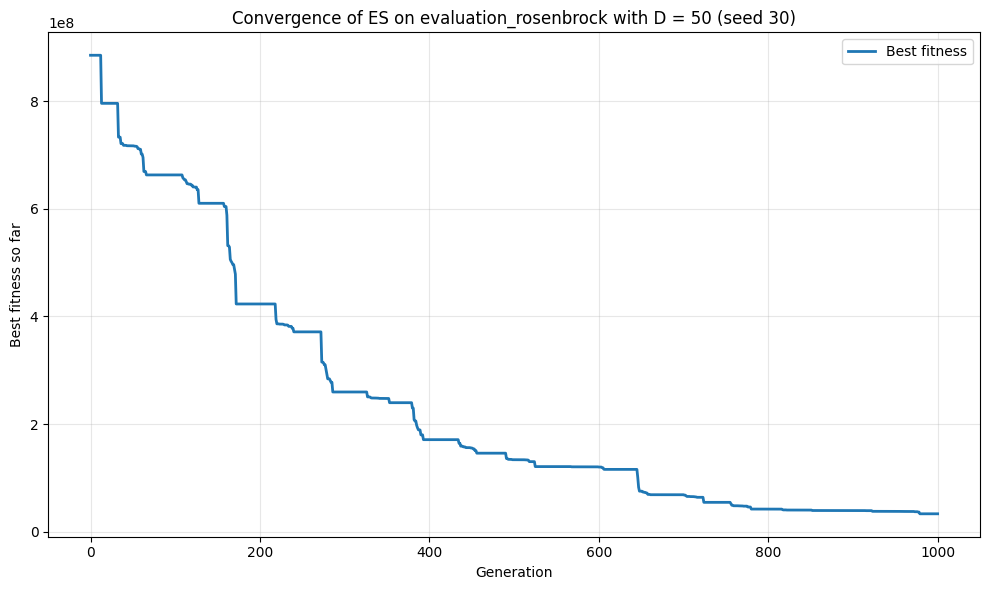

In [7]:
# Plot the latest seed's convergence.
generations = np.arange(len(convergence_data))

plt.figure(figsize=(10, 6))
plt.plot(generations, convergence_data, label="Best fitness", linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title(f"Convergence of ES on {EVALUATION_FUNC_NAME} with D = {NUM_DECISION_VARIABLES} (seed {seed_list[-1]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()